# OpenAI API - options avancées

## Paramètres de génération – llama-server et SDK OpenAI

Les défauts indiqués sont ceux de `llama-server` (à vérifier avec `GET /props`, ils changent d'une version à l'autre), **pas** ceux d'OpenAI. Si vous ne passez aucun paramètre, ce sont les défauts du serveur qui s'appliquent.

| Paramètre | Ce qu'il fait | Défaut serveur | Valeurs courantes | Effet concret et pièges | Comment le passer |
|---|---|---|---|---|---|
| `temperature` | Divise les logits avant le softmax : basse = distribution piquée, haute = aplatie | 0.8 | 0 (déterministe), 0.2-0.5 (factuel, code), 0.7-1.0 (conversation), 1.2+ (créatif) | À 0, toujours le token le plus probable → même réponse à chaque appel. Au-delà de 1.5 le texte part en charabia. Appliqué **en dernier** dans la chaîne de llama.cpp | `temperature=` |
| `top_k` | Ne garde que les *k* tokens les plus probables | 40 | 20-100 ; 0 = désactivé | `top_k=1` = glouton, la température n'a plus aucun effet. Filtre brutal : ignore la forme de la distribution | `extra_body={"top_k": ...}` |
| `top_p` (nucleus) | Ne garde que les tokens dont les probabilités cumulées atteignent *p* | 0.95 | 0.9-0.95 ; 1.0 = désactivé | S'adapte à la distribution : peu de candidats si le modèle est sûr, beaucoup s'il hésite. Laisse passer des tokens très improbables quand la queue est longue | `top_p=` |
| `min_p` | Élimine les tokens dont la probabilité est < *p* × celle du meilleur | 0.05 | 0.02-0.1 ; 0 = désactivé | Spécifique llama.cpp. Souvent préféré à `top_p` sur les petits modèles : coupe la queue sans limiter la diversité quand le modèle hésite vraiment. Permet des températures plus hautes sans charabia | `extra_body={"min_p": ...}` |
| `seed` | Initialise le générateur aléatoire | -1 (aléatoire) | n'importe quel entier | Même prompt + même seed + mêmes paramètres = même réponse, même à `temperature=1`. Indispensable pour un exercice reproductible. Ne garantit rien si le serveur ou le batch change | `seed=` |
| `max_tokens` | Nombre maximal de tokens générés | -1 (jusqu'à la fin du contexte) | 50-2000 selon l'usage | Coupe net : `finish_reason == "length"`, phrase inachevée. Trop bas = réponses tronquées ; trop haut = un modèle qui boucle remplit tout le contexte | `max_tokens=` |
| `stop` | Chaînes qui arrêtent la génération dès qu'elles apparaissent | aucune | `["\n"]`, `["###"]`, `["4."]` | La chaîne d'arrêt n'est pas renvoyée. Sert à contrôler le format sans grammaire : arrêter après une ligne, après 3 items | `stop=[...]` |
| `repeat_penalty` | Divise les logits des tokens déjà vus dans les `repeat_last_n` derniers | 1.0 (désactivé) | 1.05-1.2 | Contre les boucles « banane banane banane ». Trop haut : le modèle évite des mots nécessaires (ponctuation, articles) et devient incohérent. Pénalise aussi les tokens du prompt | `extra_body={"repeat_penalty": ...}` |
| `frequency_penalty` | Soustrait *f* × (nombre d'occurrences) au logit | 0 | 0.1-0.5 | Pénalité proportionnelle : plus un token revient, plus il est pénalisé. Réduit les répétitions de vocabulaire | `frequency_penalty=` |
| `presence_penalty` | Soustrait *p* au logit de tout token déjà apparu, une fois | 0 | 0.1-0.5 | Pénalité fixe : encourage à aborder de nouveaux sujets plutôt que répéter. Complémentaire de `frequency_penalty` | `presence_penalty=` |
| `dry_multiplier` | Sampler DRY : pénalise la répétition de **séquences** (n-grammes), pas de tokens isolés | 0 (désactivé) | 0.8 | Plus fin que `repeat_penalty` : cible les boucles de phrases entières sans toucher aux mots courants. Utile en écriture longue | `extra_body={"dry_multiplier": ...}` |
| `logprobs` / `top_logprobs` | Renvoie les log-probabilités des tokens choisis et des *n* meilleurs candidats | désactivé | `top_logprobs=5` à 20 | Ne change pas la génération, rend la distribution visible. `math.exp(logprob)` donne la probabilité. Outil pédagogique n°1 pour expliquer tous les autres paramètres | `logprobs=True, top_logprobs=` |
| `n_probs` | Équivalent natif llama.cpp de `top_logprobs` | 0 | 5-20 | Même chose, sur l'endpoint `/completion` | `extra_body={"n_probs": ...}` |
| `cache_prompt` | Réutilise le KV cache du préfixe commun avec la requête précédente | true | true/false | N'affecte pas le texte, seulement `prompt_ms`. Le désactiver rend l'effet du cache mesurable | `extra_body={"cache_prompt": False}` |
| `response_format` / `json_schema` / `grammar` | Contraint la sortie à un format via une grammaire GBNF | aucun | schéma JSON, grammaire | Le sampler ne peut choisir que des tokens valides pour la grammaire. Voir la section « Sorties structurées » | `response_format=`, `extra_body={"grammar": ...}` |

### Remarques

#### L'ordre d'application compte

llama.cpp enchaîne les samplers dans un ordre fixe par défaut :

```
pénalités → DRY → top_k → typical_p → top_p → min_p → temperature
```

La température arrive en dernier, ce qui explique que `top_k=1` la neutralise, et que `min_p` filtre sur les probabilités *avant* réchauffement. L'ordre est modifiable au lancement du serveur avec `--samplers`.

#### Ne pas tout régler à la fois

Partir de `temperature` seule, tout le reste aux défauts. Puis ajouter **un seul** filtre (`min_p` ou `top_p`, pas les deux). Les pénalités seulement si nous observons des boucles. Modifier cinq paramètres d'un coup rend impossible de savoir lequel a eu quel effet.

#### Paramètres non standard et SDK OpenAI

Le SDK ne connaît que les paramètres de l'API OpenAI (`temperature`, `top_p`, `seed`, `max_tokens`, `stop`, `frequency_penalty`, `presence_penalty`, `logprobs`, `top_logprobs`, `response_format`). Tout paramètre propre à llama.cpp (`top_k`, `min_p`, `repeat_penalty`, `dry_multiplier`, `cache_prompt`, `grammar`, `n_probs`, `chat_template_kwargs`) passe par `extra_body={...}` : le SDK ajoute ces clés telles quelles au JSON envoyé au serveur.

In [79]:
import requests as rq
import json
from openai import OpenAI
from gguf import GGUFReader
from pathlib import Path
import base64

from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

from pydantic import BaseModel
from typing import Literal
from datetime import date

from IPython.display import Markdown

In [2]:
BASE_URL = 'http://100.85.184.14:8080'
r = rq.get(f'{BASE_URL}/health')
print(r.status_code)

200


In [3]:
client = OpenAI(
    base_url=f'{BASE_URL}/v1',
    api_key = 'no-sk'
)

client.models.list().data[0].id

'/home/rwauman/models/qwen3.8-27b/llama/Qwen3.8-27B-UD-Q4_K_XL.gguf'

In [4]:
r = client.chat.completions.create(
    model = 'local',
    messages = [
        {'role': 'system', 'content': 'Réponds en un seul mot et en français à la question.'},
        {'role': 'user', 'content': 'Miroir, miroir, suis-je le plus beau ?'}
        ],
    max_tokens=1,
    logprobs=True,
    top_logprobs=5,
    extra_body={'chat_template_kwargs': {'enable_thinking': False}}
)


for token in r.choices[0].logprobs.content[0].top_logprobs:
    print(f'{token.token}: {np.round(np.exp(token.logprob), 2)*100} %')


Non: 41.0 %
Oui: 38.0 %
Pe: 5.0 %
M: 4.0 %
Abs: 1.0 %


### Contrôle de la température

In [ ]:
for i in range(5):
    r = client.chat.completions.create(
        model='local',
        messages=[{'role': 'user', 'content': 'Donne-moi un prénom francophone'}],
        temperature=0
    )

    pprint(r.choices[0].message.content)

'Léa'
'Léa'
'Léa'
'Léa'
'Léa'


In [7]:
for i in range(10):
    r = client.chat.completions.create(
            model='local',
            messages=[{'role': 'user', 'content': 'Donne-moi un prénom francophone et invente un nom de famille'}],
            temperature=1.8
    )
    pprint(r.choices[0].message.content)

'Camille Vauclair'
'Hugo Drevillon'
'**Éloise Marchebrun**'
'Amara Valdremont'
'Prénom : Léonard\nNom de famille inventé : Vauban'
'Camille Vauclair'
'Prénom : **Léonie**  \nNom inventé : **Devalon**'
'Camille Dubreuil'
'**Léa Delvaux**'
'**Prénom francophone :** Camille  \n**Nom de famille inventé :** Laveline'


## Gestion des images

Les LLM actuels sont multimodaux, mais ce n'est pas magique. Il faut ajouter des modèles à part afin de pouvoir gérer autre chose que du texte (*e.g.* images, sons, *etc.*).

Les modèles sont souvent accompagnés d'un fichier `.mmproj` (*multimodal projector*). Ce sont de petits modèles qui ont pour objectif de projeter les entrées (ici les images) directement dans l'espace de vecteurs du LLM, et non de les convertir en mots. Ils ne décrivent pas le contenu des images en texte qui serait ensuite injecté dans le prompt. C'est assez différent d'un OCR, qui ne fait qu'une retranscription exacte d'une image : un OCR ne « raisonne » pas dessus.

Avec llama-server :
```sh
llama-server -m $M/qwen3.8-27b/llama/Qwen3.8-27B-UD-Q4_K_XL.gguf \
 -ngl 99 -c 65536 -fa on \
 --port 8080 --host 0.0.0.0 -np 1 \
 --mmproj $M/qwen3.8-27b/llama/mmproj-F16.gguf
```

À noter qu'il est possible d'*offload* le projecteur sur le CPU via `--no-mmproj-offload`, ce qui libère un peu de VRAM au prix d'un encodage des images plus lent.

Le `content` de l'utilisateur devient une liste où nous passons notre prompt et nos images en base64. Il devient nécessaire de typer chaque entrée (`text` ou `image_url`) pour que le modèle sache s'il s'agit de texte ou d'une image. Le format `data:<mime>;base64,<données>` est une *data URL* : l'image est embarquée dans la requête au lieu d'être téléchargée depuis une adresse.

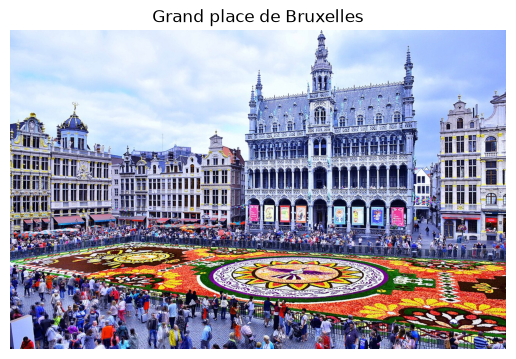

image/jpeg


'...'

In [37]:
MIME_TYPE = {
    'jpg': 'image/jpeg',
    'jpeg': 'image/jpeg',
    'png': 'image/png'
}

img_path = Path('files/00_image.jpg')

plt.title('Grand place de Bruxelles')
plt.imshow(plt.imread(img_path))
plt.axis('off')
plt.show()

img_mime_type = MIME_TYPE.get(img_path.suffix.lstrip('.').lower())
print(img_mime_type)

img = base64.b64encode(img_path.read_bytes()).decode()
img

In [22]:
r = client.chat.completions.create(
    model = 'local'
    , messages=[{
        'role': 'user',
        'content': [
            {'type': 'text', 'text': 'Décris-moi cette image. Arrives-tu à savoir où elle a été prise et lors de quel évènement ?'},
            {'type': 'image_url', 'image_url': {'url': f'data:{img_mime_type};base64,{img}'}}
            ]
    }]
)
pprint(r.choices[0].message.content)

("**Description de l'image**\n"
 '\n'
 'On voit une vaste place urbaine pavée, dont le centre est entièrement '
 "recouvert d'un immense **tapis floral** aux couleurs vives. Ce tapis est "
 'composé de motifs symétriques : de grands cercles concentriques, des « '
 'soleils » rayonnants, des volutes et des formes de fleurs, assemblés en '
 'mosaïque avec des tons rouges, jaunes, orangés, blancs, violets, verts et '
 'bruns. Autour de cette œuvre, une foule nombreuse de visiteurs circule ou '
 "s'arrête ; une partie d'entre eux est contenue par des barrières métalliques "
 "qui délimitent la zone du tapis, tandis que d'autres promènent plus "
 'librement au premier plan. Beaucoup portent des vêtements de saison chaude '
 '(t‑shirts, chemises légères) et on aperçoit ici et là des parapluies.\n'
 '\n'
 "En arrière-plan, la place est encadrée d'édifices historiques somptueux. Au "
 'centre‑droit se dresse un grand bâtiment blanc et gris, richement sculpté, '
 "avec des pignons élancés, une 

### Tokens

Les images consomment des tokens et du contexte. Le projecteur découpe l'image en *patches* et chacun devient un token du prompt : selon la résolution, une image représente de quelques centaines à plus d'un millier de tokens. `prompt_n` et `prompt_ms` dans les `timings` le reflètent directement.

In [25]:
r.model_extra

{'timings': {'cache_n': 42,
  'prompt_n': 1076,
  'prompt_ms': 1689.27,
  'prompt_per_token_ms': 1.569953531598513,
  'prompt_per_second': 636.961527760512,
  'predicted_n': 1396,
  'predicted_ms': 19171.674,
  'predicted_per_token_ms': 13.743135483870967,
  'predicted_per_second': 72.76359904721936,
  'draft_n': 1254,
  'draft_n_accepted': 768}}

## Sorties structurées

Jusqu'à présent nos sorties étaient libres, le modèle nous répond comme si c'était une discussion. Pour une série de tâches, le LLM n'est qu'un intermédiaire dont la réponse doit être exploitée de manière automatique. Avec une sortie libre, c'est voué à l'échec.

Il est donc possible de formater les sorties afin que nous puissions les exploiter facilement. La façon la plus classique est de demander une sortie en JSON.

Pour l'exemple, prenons un ticket de caisse. Dans un cas réel, un OCR serait probablement plus adapté.

Le paramètre `response_format` permet de demander un JSON en sortie. Avec `{'type': 'json_object'}`, llama-server garantit un JSON syntaxiquement valide, mais c'est le modèle qui choisit les clés.

À noter également que, pour ce genre de tâche, il est plutôt conseillé de ne pas utiliser le mode raisonnement.

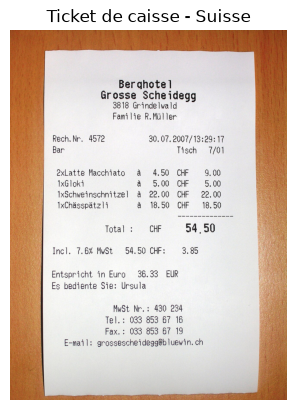

In [39]:
def convert_img_to_b64(img_path: Path) -> dict:
    img_mime_type = MIME_TYPE.get(img_path.suffix.lstrip('.').lower())
    img_b64 = base64.b64encode(img_path.read_bytes()).decode()
    return {'url': f'data:{img_mime_type};base64,{img_b64}'}

img_path = Path('files/01_image.jpg')

plt.title('Ticket de caisse - Suisse')
plt.imshow(plt.imread(img_path))
plt.axis('off')
plt.show()

In [46]:
r = client.chat.completions.create(
    model='local',
    messages=[
        {'role': 'system', 'content': "Tu es un parseur de tickets (restaurants, courses, etc.). Ton rôle est d'extraire les différentes lignes avec description et montant, le montant total, le lieu et tout ce qui te semblera pertinent."},
        {'role': 'user', 'content': [{'type': 'image_url', 'image_url': convert_img_to_b64(img_path)}]}       
    ]
    , response_format={'type': 'json_object'}
)
data = json.loads(r.choices[0].message.content)
pprint(data)

{'adresse': '3818 Grindelwald',
 'coordonnees': {'email': 'grossescheidegg@bluewin.ch',
                 'fax': '033 853 67 19',
                 'numero_tva': '430 234',
                 'telephone': '033 853 67 16'},
 'date': '30.07.2007',
 'equivalent_euro': '36.33 EUR',
 'exploitation': 'Famille R. Müller',
 'heure': '13:29:17',
 'lignes': [{'description': 'Latte Macchiato',
             'montant': '9.00 CHF',
             'prix_unitaire': '4.50 CHF',
             'quantite': 2},
            {'description': 'Gloki',
             'montant': '5.00 CHF',
             'prix_unitaire': '5.00 CHF',
             'quantite': 1},
            {'description': 'Schweinschnitzel',
             'montant': '22.00 CHF',
             'prix_unitaire': '22.00 CHF',
             'quantite': 1},
            {'description': 'Chässpätzli',
             'montant': '18.50 CHF',
             'prix_unitaire': '18.50 CHF',
             'quantite': 1}],
 'numero_compte': '4572',
 'restaurant': 'Berghotel Gross

### Avec schéma prédéfini

L'inconvénient de la solution précédente est que nous ne contrôlons pas le JSON. Nous ne connaissons pas sa structure, ses clés, et nous n'avons aucune garantie que ce schéma soit stable d'un appel à l'autre.

Il est donc possible d'en définir un avec un *JSON Schema* : un objet de type `object` avec une liste de `properties`, chacune typée, et éventuellement la liste des clés `required`. Llama-server convertit ce schéma en grammaire et le modèle ne peut alors générer que des tokens qui la respectent.

Le schéma ci-dessous décrit un ticket : quelques champs simples et une liste d'articles, chacun étant lui-même un objet. Les mêmes clés sont reprises dans la classe pydantic de la section suivante.

In [65]:
schema = {
    'type': 'object',
    'properties': {
        'lieu': {'type': 'string'},
        'type_lieu': {'type': 'string', 'enum': ['restaurant', 'supermarche', 'commerce']},
        'date': {'type':'string'},
        'devise': {'type': 'string'},
        'total': {'type': 'number'},
        'articles': {
            'type': 'array',
            'items': {
                'type': 'object',
                'properties': {
                    'nom': {'type': 'string'},
                    'quantite': {'type': 'number'},
                    'prix_unitaire': {'type': 'number'},
                    'total': {'type': 'number'}
                },
            'required': ['nom', 'quantite', 'prix_unitaire', 'total']
            }
        }
    }
    , 'required': ['lieu', 'type_lieu', 'date', 'devise', 'total', 'articles']
}

r = client.chat.completions.create(
    model = 'local',
    messages=[
        {'role': 'system', 'content': "Tu es un parseur de tickets (restaurants, courses, etc.). Ton rôle est d'extraire les différentes lignes avec description et montant, le montant total, le lieu et tout ce qui te semblera pertinent."},
        {'role': 'user', 'content': [{'type': 'image_url', 'image_url': convert_img_to_b64(img_path)}]}   
    ]
    , response_format={'type': 'json_schema', 'json_schema': {'name': 'ticket', 'schema': schema}}
)

data = json.loads(r.choices[0].message.content)
pprint(data)

{'article': [{'nom': 'Latte Macchiato',
              'prix_unitaire': 4.5,
              'quantite': 2,
              'total': 9.0},
             {'nom': 'Gloki',
              'prix_unitaire': 5.0,
              'quantite': 1,
              'total': 5.0},
             {'nom': 'Schweinschnitzel',
              'prix_unitaire': 22.0,
              'quantite': 1,
              'total': 22.0},
             {'nom': 'Chässpätzli',
              'prix_unitaire': 18.5,
              'quantite': 1,
              'total': 18.5}],
 'date': '30.07.2007',
 'devise': 'CHF',
 'lieu': 'Berghotel Grosse Scheidegg',
 'total': 54.5,
 'type_lieu': 'restaurant'}


### Pydantic et OO

Nous venons de le voir : écrire un schéma à la main, c'est assez long et surtout truffé d'erreurs dès qu'il devient complexe.

L'idée est de créer une classe avec une validation pydantic, ce qui permet de générer le schéma (`model_json_schema()`) et de valider la réponse (`model_validate_json()`) avec la même définition.

In [70]:
class Article(BaseModel):
    nom: str
    quantite: int
    prix_unitaire: float
    total: float

class Ticket(BaseModel):
    lieu: str
    type_lieu: Literal['restaurant', 'supermarche', 'commerce']
    date: date
    devise: str
    total: float
    articles: list[Article]

Ticket.model_json_schema()

{'$defs': {'Article': {'properties': {'nom': {'title': 'Nom',
     'type': 'string'},
    'quantite': {'title': 'Quantite', 'type': 'integer'},
    'prix_unitaire': {'title': 'Prix Unitaire', 'type': 'number'},
    'total': {'title': 'Total', 'type': 'number'}},
   'required': ['nom', 'quantite', 'prix_unitaire', 'total'],
   'title': 'Article',
   'type': 'object'}},
 'properties': {'lieu': {'title': 'Lieu', 'type': 'string'},
  'type_lieu': {'enum': ['restaurant', 'supermarche', 'commerce'],
   'title': 'Type Lieu',
   'type': 'string'},
  'date': {'format': 'date', 'title': 'Date', 'type': 'string'},
  'devise': {'title': 'Devise', 'type': 'string'},
  'total': {'title': 'Total', 'type': 'number'},
  'articles': {'items': {'$ref': '#/$defs/Article'},
   'title': 'Articles',
   'type': 'array'}},
 'required': ['lieu', 'type_lieu', 'date', 'devise', 'total', 'articles'],
 'title': 'Ticket',
 'type': 'object'}

In [ ]:
r = client.chat.completions.create(
    model='local',
    messages=[
        {'role': 'system', 'content': "Tu es un parseur de tickets (restaurants, courses, etc.). Ton rôle est d'extraire les différentes lignes avec description et montant, le montant total, le lieu et tout ce qui te semblera pertinent."},
        {'role': 'user', 'content': [{'type': 'image_url', 'image_url': convert_img_to_b64(img_path)}]}   
    ],
    response_format={'type': 'json_schema', 'json_schema': {'name': 'ticket', 'schema': Ticket.model_json_schema()}}
)

data = Ticket.model_validate_json(r.choices[0].message.content)

for article in data.articles:
    print(article.nom)
pprint(data.model_dump_json())


Latte Macchiato
Gloki
Schweinschnitzel
Chässpätzli
('{"lieu":"Berghotel Grosse '
 'Scheidegg","type_lieu":"restaurant","date":"3007-07-20","devise":"CHF","total":54.5,"articles":[{"nom":"Latte '
 'Macchiato","quantite":2,"prix_unitaire":4.5,"total":9.0},{"nom":"Gloki","quantite":1,"prix_unitaire":5.0,"total":5.0},{"nom":"Schweinschnitzel","quantite":1,"prix_unitaire":22.0,"total":22.0},{"nom":"Chässpätzli","quantite":1,"prix_unitaire":18.5,"total":18.5}]}')


Le SDK OpenAI possède un raccourci (*i.e.* `client.chat.completions.parse`), mais il ne fonctionne pas avec tous les schémas.

Ce raccourci génère le schéma à partir de la classe pydantic et valide la réponse d'une seule traite : le résultat est directement disponible dans `message.parsed`.

In [76]:
r = client.chat.completions.parse(
    model='local',
    messages=[
        {'role': 'system', 'content': "Tu es un parseur de tickets (restaurants, courses, etc.). Ton rôle est d'extraire les différentes lignes avec description et montant, le montant total, le lieu et tout ce qui te semblera pertinent."},
        {'role': 'user', 'content': [{'type': 'image_url', 'image_url': convert_img_to_b64(img_path)}]}   
    ],
    response_format=Ticket
)
data = r.choices[0].message.parsed
pprint(data)

Ticket(lieu='Berghotel Grosse Scheidegg, 3818 Grindelwald', type_lieu='restaurant', date=datetime.date(3007, 7, 20), devise='CHF', total=54.5, articles=[Article(nom='Latte Macchiato', quantite=2, prix_unitaire=4.5, total=9.0), Article(nom='Gloki', quantite=1, prix_unitaire=5.0, total=5.0), Article(nom='Schweinschnitzel', quantite=1, prix_unitaire=22.0, total=22.0), Article(nom='Chässpätzli', quantite=1, prix_unitaire=18.5, total=18.5)])


### Grammaire et GBNF (GGML BNF)

Il est également possible d'avoir une sortie qui ne soit pas du JSON mais autre chose. Par exemple un tableau Markdown, de l'HTML, *etc.*

GBNF permet de définir une grammaire, c'est-à-dire une liste de règles.

Dans notre cas, une règle, c'est une propriété dont nous définissons la grammaire, c'est-à-dire la manière dont elle doit s'écrire. La règle `root` est le point de départ ; les autres règles sont référencées par leur nom, les chaînes entre guillemets sont littérales et les crochets définissent des classes de caractères, comme dans une expression régulière.

Il est souvent très utile de donner un exemple du résultat attendu dans le prompt system : la grammaire contraint la forme, l'exemple aide le modèle à remplir le fond.

In [85]:
grammaire = r'''
root     ::= entete "*" jour "/" mois "/" annee "*\n\n" table "\n**Total : " prix " " devise "**\n"
entete   ::= "### " texte " — " typelieu "\n"
typelieu ::= "restaurant" | "supermarche" | "commerce"
table    ::= "| Article | Qté | Prix unit. | Total |\n|---|---:|---:|---:|\n" ligne+
ligne    ::= "| " texte " | " entier " | " prix " | " prix " |\n"
texte    ::= [^|\n]+
entier   ::= [1-9] [0-9]*
prix     ::= [0-9]+ "." [0-9]{2}
devise   ::= [A-Z]{3} | "€"
jour     ::= [0-2] [0-9] | "3" [01]
mois     ::= "0" [1-9] | "1" [0-2]
annee    ::= "20" [0-9]{2}
'''

system_prompt = '''Tu es un parseur de tickets. Réponds exactement dans ce format, rien d'autre :

### Nom du lieu — restaurant
*12/03/2026*

| Article | Qté | Prix unit. | Total |
|---|---:|---:|---:|
| Café | 2 | 2.50 | 5.00 |
| Croissant | 1 | 1.80 | 1.80 |

**Total : 6.80 €**
'''

r = client.chat.completions.create(
    model="local",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": [{"type": "image_url", "image_url": convert_img_to_b64(img_path)}]},
    ],
    max_tokens=2000,
    extra_body={"grammar": grammaire, 'chat_template_kwargs': {'enable_thinking': False}},
)
display(Markdown(r.choices[0].message.content))

### Grosse Scheidegg — restaurant
*30/07/2007*

| Article | Qté | Prix unit. | Total |
|---|---:|---:|---:|
| Latte Macchiato | 2 | 4.50 | 9.00 |
| Gloki | 1 | 5.00 | 5.00 |
| Schweinschnitzel | 1 | 22.00 | 22.00 |
| Chässpätzli | 1 | 18.50 | 18.50 |

**Total : 54.50 €**
